In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

carpeta = "../../Datos/Datos oncológicos (procesados)"
archivos = [
    "GRD_ONCOLOGIA_PROC_2019.csv",
    "GRD_ONCOLOGIA_PROC_2020.csv",
    "GRD_ONCOLOGIA_PROC_2021.csv",
    "GRD_ONCOLOGIA_PROC_2022.csv",
    "GRD_ONCOLOGIA_PROC_2023.csv",
    "GRD_ONCOLOGIA_PROC_2024.csv"
]


Edad:
Para capturar el riesgo demográfico, se derivó la característica continua EDAD a partir de la diferencia entre FECHA_INGRESO y FECHA_NACIMIENTO. Durante la auditoría del proceso, se aplicaron las siguientes medidas metodológicas:

Corrección de Formatos Temporales: Se identificó y resolvió un quiebre de formato en la cohorte 2023 (registrada como dd-mm-yyyy a diferencia del estándar yyyy-mm-dd del resto de los años), evitando la generación de valores negativos o nulos artificiales.

Validación Clínica de Valores Extremos: Se constató la presencia de pacientes con Edad = 0 (lactantes menores de 1 año). Se validó su pertinencia clínica, dado que representan patologías oncológicas de la primera infancia (ej. neuroblastomas, retinoblastomas), con una incidencia (~0.15%) coherente con la epidemiología nacional.

Depuración Final: Se identificó y eliminó exactamente 1 registro en la cohorte 2024 que presentaba una fecha de ingreso inválida, imposibilitando el cálculo.


Análisis Exploratorio y Validación de la Variable "Edad"
La evaluación estadística y visual (mediante diagrama de caja) de la variable derivada EDAD en la cohorte 2019-2024 demuestra una distribución temporalmente estable y altamente coherente con la epidemiología oncológica a nivel poblacional. La edad promedio global se sitúa en 58.97 años (DE = 18.61), presentando una notable consistencia interanual, con medianas que se mantienen estables en torno a los 60 años. El rango intercuartílico (la concentración del 50% central de la muestra) se ubica consistentemente entre los 50 y 70 años, reafirmando el aumento del riesgo oncológico asociado a la adultez y senectud.

El análisis de valores atípicos (outliers) presentes en las colas de la distribución confirma que estos responden a realidades clínicas y no a corrupciones del dato:

Cola Inferior (Oncología Pediátrica): La densa concentración de valores atípicos por debajo del bigote inferior (edades entre 0 y 20 años) representa correctamente a la subpoblación de pacientes oncológicos infantiles y adolescentes, validando la integridad de los ingresos pediátricos (incluyendo lactantes con Edad = 0).

Cola Superior (Extremos Senescentes): Los escasos registros que superan los 100 años (con un máximo aislado de 118 en 2019) corresponden a pacientes centenarios o anomalías menores de digitación en el registro de origen. Dado su volumen microscópico frente a los más de 250.000 registros válidos, su impacto estadístico es nulo y no generará sesgos ni degradación en la convergencia de algoritmos predictivos robustos.

La variable se considera validada, preservando su formato numérico continuo para maximizar la ganancia de información en la fase de modelamiento.

In [12]:

estadisticas_edad = []

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    año = archivo[-8:-4]
    df = pd.read_csv(ruta, low_memory=False)

    # 1. Convertir Nacimiento (Siempre yyyy-mm-dd)
    # errors="coerce" transformará fechas inválidas en NaT (nulos) silenciosamente
    nacimiento = pd.to_datetime(df["FECHA_NACIMIENTO"], format="%Y-%m-%d", errors="coerce")

    # 2. Convertir Ingreso (Manejando la trampa del formato de 2023)
    if año == "2023":
        ingreso = pd.to_datetime(df["FECHA_INGRESO"], format="%d-%m-%Y", errors="coerce")
    else:
        ingreso = pd.to_datetime(df["FECHA_INGRESO"], format="%Y-%m-%d", errors="coerce")

    # 3. Calcular la edad cumplida en años
    edad_dias = (ingreso - nacimiento).dt.days
    edad_anios = np.floor(edad_dias / 365.25)

    # 4. Recopilar métricas de calidad
    estadisticas_edad.append({
        "Año": año,
        "Total Pacientes": len(df),
        "Nulos generados": edad_anios.isna().sum(),
        "Edades < 0 (Errores)": (edad_anios < 0).sum(),
        "Edades = 0 (Bebés)": (edad_anios == 0).sum(),
        "Edades > 100 (Centenarios)": (edad_anios > 100).sum(),
        "Mínima": edad_anios.min(),
        "Promedio": round(edad_anios.mean(), 1),
        "Máxima": edad_anios.max()
    })

# 5. Mostrar la radiografía de la variable
print("\nAUDITORÍA DE LA VARIABLE DERIVADA: EDAD\n")
pd.DataFrame(estadisticas_edad).set_index("Año")


AUDITORÍA DE LA VARIABLE DERIVADA: EDAD



,Total Pacientes,Nulos generados,Edades < 0 (Errores),Edades = 0 (Bebés),Edades > 100 (Centenarios),Mínima,Promedio,Máxima
Año,,,,,,,,
2019,45575,0,0,67,4,0.0,58.7,118.0
2020,35188,0,0,91,4,0.0,57.9,102.0
2021,38765,0,0,72,4,0.0,58.1,110.0
2022,44478,0,0,63,2,0.0,59.0,102.0
2023,51403,0,0,78,1,0.0,59.5,101.0
2024,54574,1,0,84,6,0.0,59.9,104.0


In [13]:
for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    año = archivo[-8:-4]
    df = pd.read_csv(ruta, low_memory=False)

    # 1. Convertir Nacimiento
    nacimiento = pd.to_datetime(df["FECHA_NACIMIENTO"], format="%Y-%m-%d", errors="coerce")

    # 2. Convertir Ingreso (Trampa 2023)
    if año == "2023":
        ingreso = pd.to_datetime(df["FECHA_INGRESO"], format="%d-%m-%Y", errors="coerce")
    else:
        ingreso = pd.to_datetime(df["FECHA_INGRESO"], format="%Y-%m-%d", errors="coerce")

    # 3. Calcular Edad
    df["EDAD"] = np.floor((ingreso - nacimiento).dt.days / 365.25)

    # 4. Eliminar el nulo (el caso inválido de 2024)
    df = df.dropna(subset=["EDAD"]).copy()
    
    # Asegurarnos de que quede como número entero
    df["EDAD"] = df["EDAD"].astype(int)

    # 6. Sobrescribir el archivo
    df.to_csv(ruta, index=False)

--- ESTADÍSTICAS GLOBALES DE EDAD (2019-2024) ---
Mínimo: 0
Máximo: 118
Promedio: 58.97
Desviación Estándar: 18.61

--- RESUMEN POR AÑO ---
      min   mean    std    max
AÑO                           
2019  0.0  58.72  19.22  118.0
2020  0.0  57.94  19.46  102.0
2021  0.0  58.07  18.95  110.0
2022  0.0  58.99  18.22  102.0
2023  0.0  59.54  17.99  101.0
2024  0.0  59.93  18.08  104.0


C:\Users\Carloto\AppData\Local\Temp\ipykernel_28976\899045463.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_total, x="AÑO", y="EDAD", palette="Blues")


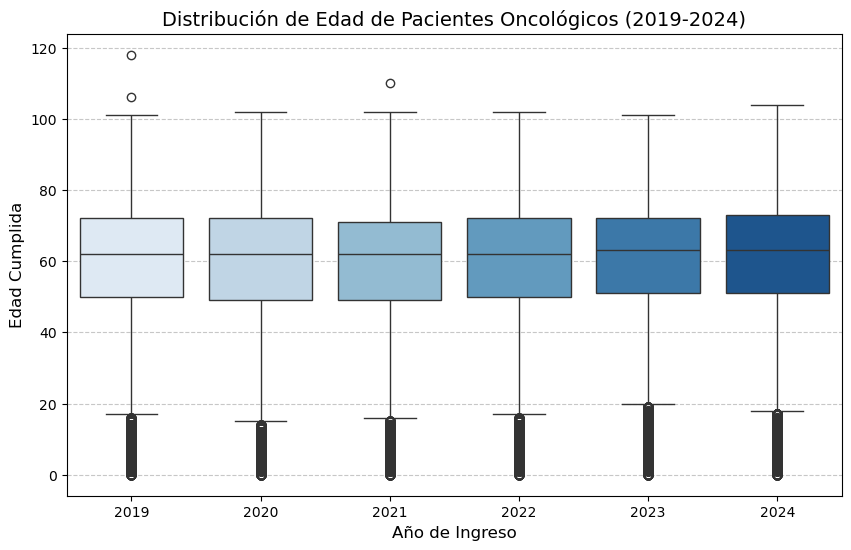

In [14]:
datos_edad = []

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    año = archivo[-8:-4]
    # Solo cargamos la columna EDAD para ahorrar memoria
    df = pd.read_csv(ruta, usecols=["EDAD"], low_memory=False)
    df["AÑO"] = año
    datos_edad.append(df)

# Unimos todos los años
df_total = pd.concat(datos_edad, ignore_index=True)

# 1. Mostrar Estadísticas Globales
print("--- ESTADÍSTICAS GLOBALES DE EDAD (2019-2024) ---")
print(f"Mínimo: {df_total['EDAD'].min()}")
print(f"Máximo: {df_total['EDAD'].max()}")
print(f"Promedio: {df_total['EDAD'].mean():.2f}")
print(f"Desviación Estándar: {df_total['EDAD'].std():.2f}")

# Mostrar resumen por año
print("\n--- RESUMEN POR AÑO ---")
print(df_total.groupby("AÑO")["EDAD"].describe()[["min", "mean", "std", "max"]].round(2))

# 2. Generar el Diagrama de Caja (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_total, x="AÑO", y="EDAD", palette="Blues")
plt.title("Distribución de Edad de Pacientes Oncológicos (2019-2024)", fontsize=14)
plt.xlabel("Año de Ingreso", fontsize=12)
plt.ylabel("Edad Cumplida", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Carga oncologica
Ingeniería de Características: Derivación de "Carga Oncológica" (Multimorbilidad Maligna)
Para capturar la complejidad del cuadro clínico y su impacto potencial en la severidad del paciente, se derivó la nueva característica continua discreta CARGA_ONCOLOGICA. Esta variable actúa como un proxy (indicador indirecto) de la extensión de la enfermedad, representando el recuento total de diagnósticos de neoplasias malignas concurrentes por episodio de hospitalización.

El proceso de extracción se realizó mediante técnicas de vectorización y expresiones regulares (Regex) sobre el vector completo de comorbilidades (desde DIAGNOSTICO1 hasta DIAGNOSTICO35). Se identificaron y contabilizaron exclusivamente aquellos códigos CIE-10 cuya raíz topográfica correspondiera a neoplasias malignas confirmadas (códigos del C00 al C97).

La generación de esta variable permite transformar una matriz dispersa y de alta dimensionalidad (35 columnas de texto categórico) en un único escalar de alto poder predictivo. Matemáticamente, garantiza un valor basal mínimo de 1 (dado el criterio de inclusión de la cohorte en DIAGNOSTICO1), mientras que los valores superiores a 1 consolidan la señal estadística asociada a la presencia de metástasis o segundos tumores primarios, factores fuertemente correlacionados con el consumo intensivo de recursos hospitalarios.

Análisis Estadístico de la Variable "Carga Oncológica"
La evaluación estadística de la variable derivada CARGA_ONCOLOGICA confirma una distribución altamente asimétrica con sesgo positivo (Right-Skewed), comportamiento esperado y coherente con la epidemiología de la multimorbilidad neoplásica.

El límite inferior se sitúa estrictamente en 1, validando la integridad del filtro de inclusión de la cohorte (pacientes con al menos un diagnóstico principal maligno). La métrica central revela un promedio global de 1.33 diagnósticos por paciente, manteniéndose sumamente estable a lo largo del sexenio 2019-2024. El análisis posicional indica que el 75% de la población (Tercer Cuartil) presenta una carga oncológica de 1, lo que explica la compresión visual del rango intercuartílico en el diagrama de caja.

Los valores superiores (de 2 a 10 diagnósticos concurrentes) son clasificados estadísticamente como atípicos (outliers) de la distribución, sin embargo, representan hallazgos clínicos de vital importancia. Esta "larga cola" de la distribución concentra a los pacientes de mayor complejidad hospitalaria, capturando la señal de estadios metastásicos, tumores diseminados o cánceres primarios múltiples. En el modelamiento predictivo, esta progresión numérica ascendente actuará como un penalizador natural, correlacionándose positivamente con la probabilidad de mayor consumo de recursos y severidad clínica.


Resultados de Distribución: El análisis de frecuencias absolutas y relativas consolidadas reafirma la naturaleza asimétrica de la variable. El 77.13% de los episodios hospitalarios presenta una carga oncológica base de 1 (diagnóstico primario único). El 16.11% presenta 2 diagnósticos malignos concurrentes, mientras que la "larga cola" de multimorbilidad severa (de 3 a 10 diagnósticos concurrentes) agrupa al 6.76% restante de la población. Esta segmentación natural proveerá al algoritmo predictivo de un gradiente claro para diferenciar casos de patología localizada versus enfermedad sistémica o metastásica avanzada.

--- ESTADÍSTICAS DE CARGA ONCOLÓGICA (2019-2024) ---
Mínima: 1
Máxima: 10
Promedio: 1.33
Desviación Estándar: 0.70

--- RESUMEN POR AÑO ---
      min  mean   std  75%   max
AÑO                             
2019  1.0  1.31  0.68  1.0   8.0
2020  1.0  1.32  0.69  1.0   8.0
2021  1.0  1.32  0.68  1.0  10.0
2022  1.0  1.32  0.69  1.0  10.0
2023  1.0  1.33  0.72  1.0   8.0
2024  1.0  1.35  0.73  1.0  10.0


C:\Users\Carloto\AppData\Local\Temp\ipykernel_28976\250247622.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_total, x="AÑO", y="CARGA_ONCOLOGICA", palette="Reds")


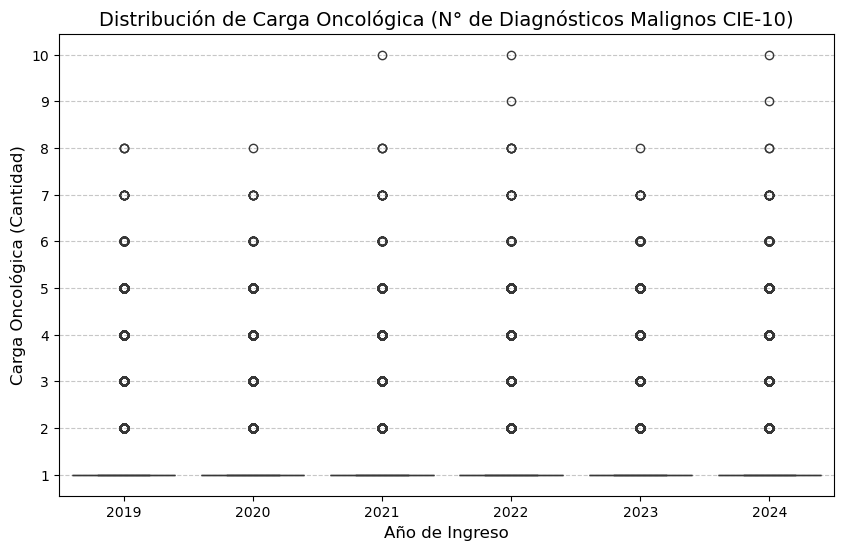

--- DISTRIBUCIÓN DE CARGA ONCOLÓGICA (2019-2024) ---
                  Total Pacientes  Porcentaje (%)
CARGA_ONCOLOGICA                                 
1                          208221           77.12
2                           43504           16.11
3                           12466            4.62
4                            4232            1.57
5                            1162            0.43
6                             313            0.12
7                              64            0.02
8                              15            0.01
9                               2            0.00
10                              3            0.00


In [15]:
datos_carga = []

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    año = archivo[-8:-4]
    
    # 1. Leer solo la cabecera para detectar cuántas columnas DIAGNOSTICO hay
    columnas_archivo = pd.read_csv(ruta, nrows=0).columns
    cols_diag = [col for col in columnas_archivo if col.startswith("DIAGNOSTICO")]
    
    # 2. Cargar solo las columnas de diagnósticos para ahorrar memoria
    df = pd.read_csv(ruta, usecols=cols_diag, low_memory=False)
    
    # 3. Inicializar el contador de carga en 0 para cada paciente
    carga_paciente = pd.Series(0, index=df.index)
    
    # 4. Evaluación vectorizada (extremadamente rápida)
    for col in cols_diag:
        # Extraemos los dos dígitos que le siguen a la letra 'C'
        num_cie10 = df[col].astype(str).str.strip().str.upper().str.extract(r'^C(\d{2})')[0].astype(float)
        
        # Evaluamos si está entre 0 y 97 (como tu función) y sumamos 1 si es True
        carga_paciente += num_cie10.between(0, 97).fillna(False).astype(int)
        
    df_resumen = pd.DataFrame({"AÑO": año, "CARGA_ONCOLOGICA": carga_paciente})
    datos_carga.append(df_resumen)

# Unimos todos los años
df_total = pd.concat(datos_carga, ignore_index=True)

# 5. Mostrar Estadísticas Globales
print("--- ESTADÍSTICAS DE CARGA ONCOLÓGICA (2019-2024) ---")
print(f"Mínima: {df_total['CARGA_ONCOLOGICA'].min()}")
print(f"Máxima: {df_total['CARGA_ONCOLOGICA'].max()}")
print(f"Promedio: {df_total['CARGA_ONCOLOGICA'].mean():.2f}")
print(f"Desviación Estándar: {df_total['CARGA_ONCOLOGICA'].std():.2f}")

# Mostrar resumen por año (agregué el percentil 75% para ver cómo se distribuye)
print("\n--- RESUMEN POR AÑO ---")
print(df_total.groupby("AÑO")["CARGA_ONCOLOGICA"].describe()[["min", "mean", "std", "75%", "max"]].round(2))

# 6. Generar el Diagrama de Caja (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_total, x="AÑO", y="CARGA_ONCOLOGICA", palette="Reds")
plt.title("Distribución de Carga Oncológica (N° de Diagnósticos Malignos CIE-10)", fontsize=14)
plt.xlabel("Año de Ingreso", fontsize=12)
plt.ylabel("Carga Oncológica (Cantidad)", fontsize=12)
# Forzamos que el eje Y muestre solo números enteros
from matplotlib.ticker import MaxNLocator
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calcular frecuencias absolutas y relativas globales
frecuencias = df_total['CARGA_ONCOLOGICA'].value_counts().sort_index()
porcentajes = df_total['CARGA_ONCOLOGICA'].value_counts(normalize=True).sort_index() * 100

tabla_freq = pd.DataFrame({
    'Total Pacientes': frecuencias,
    'Porcentaje (%)': porcentajes.round(2)
})

print("--- DISTRIBUCIÓN DE CARGA ONCOLÓGICA (2019-2024) ---")
print(tabla_freq)

In [16]:
for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    
    # 1. Cargar el dataset completo
    df = pd.read_csv(ruta, low_memory=False)
    
    # 2. Detectar dinámicamente todas las columnas de diagnóstico
    cols_diag = [col for col in df.columns if col.startswith("DIAGNOSTICO")]
    
    # 3. Inicializar el contador en 0
    carga_paciente = pd.Series(0, index=df.index)
    
    # 4. Evaluación vectorizada para sumar diagnósticos de cáncer
    for col in cols_diag:
        num_cie10 = df[col].astype(str).str.strip().str.upper().str.extract(r'^C(\d{2})')[0].astype(float)
        carga_paciente += num_cie10.between(0, 97).fillna(False).astype(int)
        
    # 5. Crear la nueva columna en el DataFrame principal
    df["CARGA_ONCOLOGICA"] = carga_paciente.astype(int)
    
    # 6. Sobrescribir el archivo original
    df.to_csv(ruta, index=False)

Ingeniería de Características: Derivación de "Número de Comorbilidades"
Para cuantificar la multimorbilidad subyacente y el nivel de fragilidad del paciente, se derivó la característica numérica discreta NUM_COMORBILIDADES. Esta métrica aísla las patologías clínicas (agudas o crónicas) concurrentes al episodio hospitalario, diferenciándolas estrictamente de la carga tumoral.

El proceso de extracción vectorizada iteró sobre la matriz completa de diagnósticos secundarios (CIE-10), aplicando un filtro algorítmico topográfico avanzado para garantizar la pureza clínica del indicador:

Aislamiento Neoplásico: Se excluyeron todos los diagnósticos clasificados en el capítulo C (Tumores Malignos) para evitar multicolinealidad con la variable CARGA_ONCOLOGICA.

Segmentación del Capítulo D: Se aplicó una división lógica sobre el capítulo D. Se excluyeron los códigos D00-D48 (Neoplasias in situ y de comportamiento incierto), pero se conservaron explícitamente los códigos D50-D89, garantizando la captura de comorbilidades hematológicas e inmunológicas críticas en oncología (ej. Anemias, Neutropenias).

Depuración Administrativa y Etiológica: Se descartaron los capítulos Z (Factores que influyen en el estado de salud, frecuentemente asociados a sesiones de control o terapias programadas) y los capítulos V, W, X, Y (Causas externas de morbilidad), limitando el conteo a procesos patológicos intrínsecos del paciente.

Esta variable otorga al modelo predictivo un escalar robusto del "peso de la enfermedad", fundamental para ajustar el riesgo asociado a los días de estada prolongados y requerimientos de soporte crítico.


Análisis Estadístico y Validación de "Número de Comorbilidades"
La evaluación cuantitativa de la variable derivada NUM_COMORBILIDADES confirma una distribución asimétrica positiva, característica de la multimorbilidad en poblaciones hospitalarias de alta complejidad. El límite inferior de la distribución se establece correctamente en 0, agrupando a un 19.87% de la cohorte que ingresa sin diagnósticos secundarios ajenos a su patología neoplásica primaria.

El promedio global se sitúa en 3.23 comorbilidades concurrentes por paciente, con una concentración masiva (más del 60% de la muestra) presentando entre 1 y 4 patologías concomitantes. Este volumen captura eficazmente el síndrome de fragilidad habitual en el paciente oncológico adulto, recogiendo diagnósticos críticos como síndromes anémicos (D50-D89) o patologías cardiovasculares crónicas.

El análisis longitudinal mediante diagrama de caja revela una notable estabilidad interanual, observándose un ligero ensanchamiento del rango intercuartílico hacia los años 2023 y 2024. Este desplazamiento captura fielmente el aumento de la complejidad clínica post-pandemia y el perfeccionamiento del proceso de codificación GRD. La larga cola derecha de la distribución, que alcanza máximos de 33 diagnósticos, representa a la subpoblación de pacientes críticos con falla multiorgánica, consolidando esta métrica como un predictor continuo altamente sensible para modelar la severidad y el consumo intensivo de recursos hospitalarios.




--- ESTADÍSTICAS DE COMORBILIDADES (2019-2024) ---
Mínima: 0
Máxima: 33
Promedio: 3.23
Desviación Estándar: 3.47

--- DISTRIBUCIÓN DE COMORBILIDADES (2019-2024) ---
                    Total Pacientes  Porcentaje (%)
NUM_COMORBILIDADES                                 
0                             53651           19.87
1                             43495           16.11
2                             44446           16.46
3                             36416           13.49
4                             26278            9.73
5                             18188            6.74
6                             12401            4.59
7                              8780            3.25
8                              6364            2.36
9                              4734            1.75
10                             3511            1.30
11                             2619            0.97
12                             2094            0.78
13                             1592            0.59
14 

C:\Users\Carloto\AppData\Local\Temp\ipykernel_28976\932469614.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_total, x="AÑO", y="NUM_COMORBILIDADES", palette="Greens")


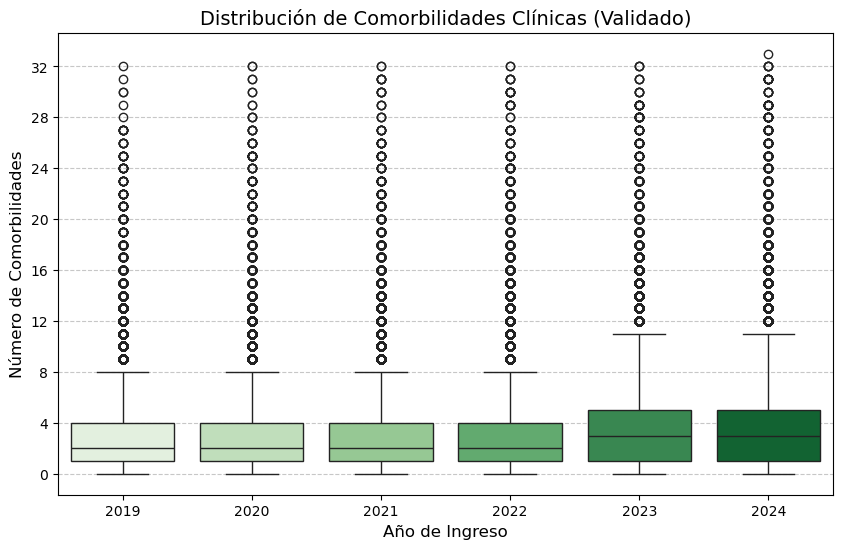

In [17]:
datos_comorbilidad = []

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    año = archivo[-8:-4]
    
    columnas_archivo = pd.read_csv(ruta, nrows=0).columns
    cols_diag = [col for col in columnas_archivo if col.startswith("DIAGNOSTICO")]
    
    df = pd.read_csv(ruta, usecols=cols_diag, low_memory=False)
    
    comorbilidades_paciente = pd.Series(0, index=df.index)
    
    for col in cols_diag:
        # 1. Limpieza inicial segura
        serie_limpia = df[col].astype(str).str.strip().str.upper().replace(["NAN", "NONE", "NULL"], np.nan)
        
        # 2. Extraer Letra y Número usando RegEx (Ej: de "D50.1" extrae "D" y "50")
        extraccion = serie_limpia.str.extract(r'^([A-Z])(\d{2})')
        letra = extraccion[0]
        numero = extraccion[1].astype(float)
        
        # 3. Reglas de Exclusión Clínicas
        excluir_c = (letra == 'C')
        excluir_d_neo = (letra == 'D') & (numero <= 48) # Excluye tumores benignos, PERO SALVA las anemias (D50+)
        excluir_admin_ext = letra.isin(['Z', 'V', 'W', 'X', 'Y'])
        
        # Unimos las condiciones de exclusión
        es_excluida = excluir_c | excluir_d_neo | excluir_admin_ext
        
        # 4. Es comorbilidad válida si tiene una letra válida y NO está en la lista de excluidas
        es_valida = letra.notna() & ~es_excluida
        
        comorbilidades_paciente += es_valida.astype(int)
        
    df_resumen = pd.DataFrame({"AÑO": año, "NUM_COMORBILIDADES": comorbilidades_paciente})
    datos_comorbilidad.append(df_resumen)

# Unimos todo
df_total = pd.concat(datos_comorbilidad, ignore_index=True)

# --- 1. ESTADÍSTICAS GLOBALES ---
print("--- ESTADÍSTICAS DE COMORBILIDADES (2019-2024) ---")
print(f"Mínima: {df_total['NUM_COMORBILIDADES'].min()}")
print(f"Máxima: {df_total['NUM_COMORBILIDADES'].max()}")
print(f"Promedio: {df_total['NUM_COMORBILIDADES'].mean():.2f}")
print(f"Desviación Estándar: {df_total['NUM_COMORBILIDADES'].std():.2f}")

# --- 2. FRECUENCIAS GLOBALES ---
frecuencias = df_total['NUM_COMORBILIDADES'].value_counts().sort_index()
porcentajes = df_total['NUM_COMORBILIDADES'].value_counts(normalize=True).sort_index() * 100

tabla_freq = pd.DataFrame({
    'Total Pacientes': frecuencias,
    'Porcentaje (%)': porcentajes.round(2)
})
print("\n--- DISTRIBUCIÓN DE COMORBILIDADES (2019-2024) ---")
print(tabla_freq.head(15))

# --- 3. DIAGRAMA DE CAJA ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_total, x="AÑO", y="NUM_COMORBILIDADES", palette="Greens")
plt.title("Distribución de Comorbilidades Clínicas (Validado)", fontsize=14)
plt.xlabel("Año de Ingreso", fontsize=12)
plt.ylabel("Número de Comorbilidades", fontsize=12)
from matplotlib.ticker import MaxNLocator
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
# Letras CIE-10 para exclusión directa (Causas externas y administrativas)
letras_excluidas = ['Z', 'V', 'W', 'X', 'Y']

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    
    # 1. Cargar el dataset completo
    df = pd.read_csv(ruta, low_memory=False)
    
    # 2. Detectar columnas de diagnóstico
    cols_diag = [col for col in df.columns if col.startswith("DIAGNOSTICO")]
    
    # 3. Inicializar el contador
    comorbilidades_paciente = pd.Series(0, index=df.index)
    
    # 4. Evaluación vectorizada con la lógica clínica validada
    for col in cols_diag:
        # Limpieza segura
        serie_limpia = df[col].astype(str).str.strip().str.upper().replace(["NAN", "NONE", "NULL"], np.nan)
        
        # Extracción de letra y número
        extraccion = serie_limpia.str.extract(r'^([A-Z])(\d{2})')
        letra = extraccion[0]
        numero = extraccion[1].astype(float)
        
        # Filtros clínicos
        excluir_c = (letra == 'C')
        excluir_d_neo = (letra == 'D') & (numero <= 48)
        excluir_admin_ext = letra.isin(letras_excluidas)
        
        es_excluida = excluir_c | excluir_d_neo | excluir_admin_ext
        es_valida = letra.notna() & ~es_excluida
        
        comorbilidades_paciente += es_valida.astype(int)
        
    # 5. Crear la nueva columna
    df["NUM_COMORBILIDADES"] = comorbilidades_paciente.astype(int)
    
    # 6. Sobrescribir el archivo
    df.to_csv(ruta, index=False)

COMORBILIDAD PRINCIPAL

Ingeniería de Características: Macro-agrupación de "Comorbilidad Principal"
Para dotar al modelo de contexto cualitativo sobre el perfil de riesgo del paciente, se generó la variable categórica COMORBILIDAD_PRINCIPAL. Esta característica identifica la primera patología no oncológica registrada (a partir del vector DIAGNOSTICO2), actuando como el principal motor de fragilidad paralela al cáncer.

Para evitar la "maldición de la dimensionalidad" intrínseca a las 317 categorías del CIE-10, se implementó una estrategia de reducción de cardinalidad mediante Expresiones Regulares (RegEx), mapeando las raíces alfanuméricas hacia 16 Macro Grupos Anatómico-Clínicos. Se aplicó estrictamente la misma lógica de exclusión validada previamente (descartando Neoplasias [C, D00-D48], contactos administrativos y causas externas [Z, V, W, X, Y]), garantizando consistencia referencial: el 19.87% de la muestra (53.647 episodios) fue clasificado como SIN_COMORBILIDAD, cifra que concuerda de manera exacta con los registros de NUM_COMORBILIDADES = 0.

El perfil epidemiológico de la cohorte validó robustamente la aproximación metodológica. Las comorbilidades predominantes recaen en el Sistema Circulatorio (20.8%) —reflejo de la alta prevalencia de hipertensión y cardiopatías en la población adulta mayor oncológica— y patologías Endocrinas y Metabólicas (12.1%), asociadas principalmente a cuadros de Diabetes Mellitus. Destaca además una captura del 6.9% en Sangre e Inmunidad, evidenciando la carga de síndromes anémicos e inmunológicos propios de la progresión tumoral y toxicidad terapéutica. Esta transformación categórica proporciona al algoritmo una dimensión cualitativa densa y clínicamente interpretable para la estratificación del riesgo hospitalario.

In [19]:
datos_comorb_principal = []
letras_excluidas = ['Z', 'V', 'W', 'X', 'Y']

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    año = archivo[-8:-4]
    
    # Leer el dataset (solo las columnas necesarias)
    columnas_archivo = pd.read_csv(ruta, nrows=0).columns
    # Tomamos estrictamente desde DIAGNOSTICO2 en adelante
    cols_diag = [col for col in columnas_archivo if col.startswith("DIAGNOSTICO") and col != "DIAGNOSTICO1"]
    
    df = pd.read_csv(ruta, usecols=cols_diag, low_memory=False)
    
    # Inicializamos una serie vacía (NaN) para todos los pacientes
    comorb_principal = pd.Series(np.nan, index=df.index)
    
    # Recorremos de izquierda a derecha (Diag 2 al 35)
    for col in cols_diag:
        serie_limpia = df[col].astype(str).str.strip().str.upper().replace(["NAN", "NONE", "NULL"], np.nan)
        extraccion = serie_limpia.str.extract(r'^([A-Z])(\d{2})')
        letra = extraccion[0]
        numero = extraccion[1].astype(float)
        
        # Filtros de exclusión
        excluir_c = (letra == 'C')
        excluir_d_neo = (letra == 'D') & (numero <= 48)
        excluir_admin_ext = letra.isin(letras_excluidas)
        es_invalida = excluir_c | excluir_d_neo | excluir_admin_ext
        es_valida = letra.notna() & ~es_invalida
        
        # Mapeo a Macro Grupos usando np.select
        condiciones_macro = [
            letra.isin(['A', 'B']), letra == 'D', letra == 'E', letra == 'F',
            letra == 'G', letra == 'H', letra == 'I', letra == 'J',
            letra == 'K', letra == 'L', letra == 'M', letra == 'N',
            letra.isin(['O', 'P', 'Q']), letra == 'R', letra.isin(['S', 'T']), letra == 'U'
        ]
        opciones_macro = [
            "INFECCIOSAS Y PARASITARIAS", "SANGRE E INMUNIDAD", "ENDOCRINAS Y METABOLICAS", "TRASTORNOS MENTALES",
            "SISTEMA NERVIOSO", "OJO Y OIDO", "SISTEMA CIRCULATORIO", "SISTEMA RESPIRATORIO",
            "SISTEMA DIGESTIVO", "PIEL Y TEJIDO SUBCUTANEO", "SISTEMA MUSCULOESQUELETICO", "SISTEMA GENITOURINARIO",
            "MATERNO-INFANTILES Y CONGENITAS", "SINTOMAS Y HALLAZGOS", "TRAUMATISMOS Y ENVENENAMIENTOS", "CODIGOS PROVISIONALES (COVID)"
        ]
        
        macro_col = pd.Series(np.select(condiciones_macro, opciones_macro, default=np.nan), index=df.index)
        
        # Actualizamos la comorbilidad SOLO a los pacientes que aún tienen NaN y la columna actual es válida
        mascara_actualizar = comorb_principal.isna() & es_valida
        comorb_principal.loc[mascara_actualizar] = macro_col.loc[mascara_actualizar]
        
    # Al final, los que sigan en NaN es porque no tuvieron nada válido
    comorb_principal = comorb_principal.fillna("SIN_COMORBILIDAD")
    
    df_resumen = pd.DataFrame({"AÑO": año, "COMORBILIDAD_PRINCIPAL": comorb_principal})
    datos_comorb_principal.append(df_resumen)

# Unimos todo para el análisis
df_total = pd.concat(datos_comorb_principal, ignore_index=True)

# --- FRECUENCIAS GLOBALES ---
frecuencias = df_total['COMORBILIDAD_PRINCIPAL'].value_counts()
porcentajes = df_total['COMORBILIDAD_PRINCIPAL'].value_counts(normalize=True) * 100

tabla_freq = pd.DataFrame({
    'Total Pacientes': frecuencias,
    'Porcentaje (%)': porcentajes.round(2)
})

print("--- DISTRIBUCIÓN DE MACRO COMORBILIDADES PRINCIPALES (2019-2024) ---")
print(tabla_freq.to_string())

C:\Users\Carloto\AppData\Local\Temp\ipykernel_28976\1201402043.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['SISTEMA DIGESTIVO' 'SISTEMA CIRCULATORIO' 'ENDOCRINAS Y METABOLICAS' ...
 'SISTEMA RESPIRATORIO' 'ENDOCRINAS Y METABOLICAS' 'SISTEMA CIRCULATORIO']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comorb_principal.loc[mascara_actualizar] = macro_col.loc[mascara_actualizar]
C:\Users\Carloto\AppData\Local\Temp\ipykernel_28976\1201402043.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['SISTEMA DIGESTIVO' 'INFECCIOSAS Y PARASITARIAS'
 'CODIGOS PROVISIONALES (COVID)' ... 'SISTEMA RESPIRATORIO'
 'SISTEMA CIRCULATORIO' 'SISTEMA CIRCULATORIO']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comorb_principal.loc[mascara_actu

--- DISTRIBUCIÓN DE MACRO COMORBILIDADES PRINCIPALES (2019-2024) ---
                                 Total Pacientes  Porcentaje (%)
COMORBILIDAD_PRINCIPAL                                          
SISTEMA CIRCULATORIO                       56174           20.81
SIN_COMORBILIDAD                           53651           19.87
ENDOCRINAS Y METABOLICAS                   32775           12.14
SISTEMA DIGESTIVO                          25853            9.58
SANGRE E INMUNIDAD                         18742            6.94
SISTEMA GENITOURINARIO                     16493            6.11
SISTEMA RESPIRATORIO                       16308            6.04
SINTOMAS Y HALLAZGOS                       12654            4.69
TRASTORNOS MENTALES                         7588            2.81
TRAUMATISMOS Y ENVENENAMIENTOS              7156            2.65
SISTEMA MUSCULOESQUELETICO                  6186            2.29
SISTEMA NERVIOSO                            5941            2.20
INFECCIOSAS Y PARASIT

In [20]:
letras_excluidas = ['Z', 'V', 'W', 'X', 'Y']

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    
    # 1. Cargar el dataset completo
    df = pd.read_csv(ruta, low_memory=False)
    
    # 2. Identificar columnas (estrictamente desde DIAGNOSTICO2)
    cols_diag = [col for col in df.columns if col.startswith("DIAGNOSTICO") and col != "DIAGNOSTICO1"]
    
    # 3. Inicializar la serie de comorbilidad principal
    comorb_principal = pd.Series(np.nan, index=df.index)
    
    # 4. Evaluación y mapeo vectorizado
    for col in cols_diag:
        serie_limpia = df[col].astype(str).str.strip().str.upper().replace(["NAN", "NONE", "NULL"], np.nan)
        extraccion = serie_limpia.str.extract(r'^([A-Z])(\d{2})')
        letra = extraccion[0]
        numero = extraccion[1].astype(float)
        
        # Filtros de exclusión
        excluir_c = (letra == 'C')
        excluir_d_neo = (letra == 'D') & (numero <= 48)
        excluir_admin_ext = letra.isin(letras_excluidas)
        es_invalida = excluir_c | excluir_d_neo | excluir_admin_ext
        es_valida = letra.notna() & ~es_invalida
        
        # Mapeo a Macro Grupos
        condiciones_macro = [
            letra.isin(['A', 'B']), letra == 'D', letra == 'E', letra == 'F',
            letra == 'G', letra == 'H', letra == 'I', letra == 'J',
            letra == 'K', letra == 'L', letra == 'M', letra == 'N',
            letra.isin(['O', 'P', 'Q']), letra == 'R', letra.isin(['S', 'T']), letra == 'U'
        ]
        opciones_macro = [
            "INFECCIOSAS Y PARASITARIAS", "SANGRE E INMUNIDAD", "ENDOCRINAS Y METABOLICAS", "TRASTORNOS MENTALES",
            "SISTEMA NERVIOSO", "OJO Y OIDO", "SISTEMA CIRCULATORIO", "SISTEMA RESPIRATORIO",
            "SISTEMA DIGESTIVO", "PIEL Y TEJIDO SUBCUTANEO", "SISTEMA MUSCULOESQUELETICO", "SISTEMA GENITOURINARIO",
            "MATERNO-INFANTILES Y CONGENITAS", "SINTOMAS Y HALLAZGOS", "TRAUMATISMOS Y ENVENENAMIENTOS", "CODIGOS PROVISIONALES (COVID)"
        ]
        
        macro_col = pd.Series(np.select(condiciones_macro, opciones_macro, default=np.nan), index=df.index)
        
        # Asignar solo a quienes sigan en NaN y tengan comorbilidad válida
        mascara_actualizar = comorb_principal.isna() & es_valida
        comorb_principal.loc[mascara_actualizar] = macro_col.loc[mascara_actualizar]
        
    # Rellenar a los que quedaron sin comorbilidad
    df["COMORBILIDAD_PRINCIPAL"] = comorb_principal.fillna("SIN_COMORBILIDAD")
    
    # 5. Sobrescribir
    df.to_csv(ruta, index=False)

C:\Users\Carloto\AppData\Local\Temp\ipykernel_28976\2122574697.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['SISTEMA DIGESTIVO' 'SISTEMA CIRCULATORIO' 'ENDOCRINAS Y METABOLICAS' ...
 'SISTEMA RESPIRATORIO' 'ENDOCRINAS Y METABOLICAS' 'SISTEMA CIRCULATORIO']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comorb_principal.loc[mascara_actualizar] = macro_col.loc[mascara_actualizar]
C:\Users\Carloto\AppData\Local\Temp\ipykernel_28976\2122574697.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['SISTEMA DIGESTIVO' 'INFECCIOSAS Y PARASITARIAS'
 'CODIGOS PROVISIONALES (COVID)' ... 'SISTEMA RESPIRATORIO'
 'SISTEMA CIRCULATORIO' 'SISTEMA CIRCULATORIO']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comorb_principal.loc[mascara_actu